In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

data/train.parquet
data/test.parquet
data/target_channels.csv
data/sample_submission.parquet
data/preprocessed/datasets.csv
data/output/GlobalSTD3-channels41-46.parquet
data/output/submission.csv


In [2]:
# Load channels 41-46 and ground truth from the test set
channel_names = [f"channel_{x}" for x in range(41,46 + 1)]
test_df = pd.read_parquet("data/test.parquet", columns=["id"] + channel_names)
test_df

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
0,14728321,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
1,14728322,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
2,14728323,0.808654,0.792770,0.763195,0.795242,0.821094,0.753472
3,14728324,0.806299,0.791966,0.765569,0.796030,0.820247,0.763607
4,14728325,0.809439,0.799195,0.763195,0.796816,0.821941,0.760229
...,...,...,...,...,...,...,...
521275,15249596,0.801590,0.794377,0.763987,0.788945,0.819398,0.760229
521276,15249597,0.803160,0.795180,0.764778,0.792093,0.818551,0.762762
521277,15249598,0.804729,0.796786,0.763987,0.790520,0.816006,0.763607
521278,15249599,0.806299,0.789557,0.763987,0.792881,0.816855,0.757695


In [3]:
# Calculate mean and std for each channel
test_data = test_df.loc[:, channel_names].values
means = np.mean(test_data, axis=0)
stds = np.std(test_data, axis=0)
means, stds

(array([0.8077218 , 0.78200614, 0.7672527 , 0.79397744, 0.8098512 ,
        0.764889  ], dtype=float32),
 array([0.00484659, 0.00690593, 0.00481814, 0.00595482, 0.00549068,
        0.00679178], dtype=float32))

In [10]:
# Find test samples with values outside of (mean ± N * std) for any channel
N = 3
detections = (test_data > (means + N * stds)) | (test_data < (means - N * stds))
aggregated_detections = detections.max(axis=1).astype(np.uint8)

In [12]:
# Save to submission file
submission_df = pd.DataFrame(columns=["id", "is_anomaly"])
submission_df["id"] = test_df["id"]
submission_df["is_anomaly"] = aggregated_detections
submission_df.to_parquet(f"data/LocalSTD{N}-channels-41-46.parquet")
# Generate a file supported by the Kaggle "Submit to competition" option
submission_df.to_csv(f"data/submission.csv", index=False)

In [15]:
test_df.columns

Index(['id', 'channel_41', 'channel_42', 'channel_43', 'channel_44',
       'channel_45', 'channel_46'],
      dtype='object')

<Axes: title={'center': 'Results for N=3'}, xlabel='id'>

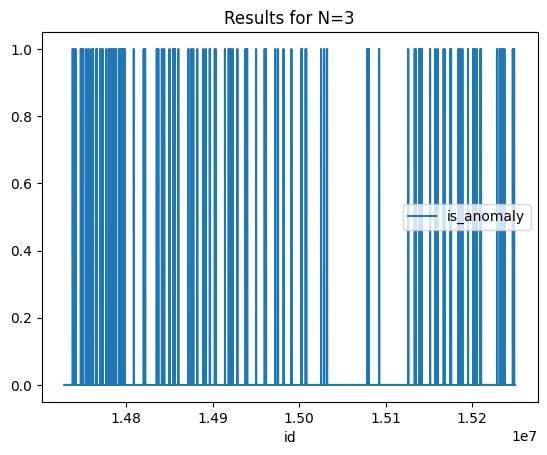

In [6]:
submission_df.plot("id", "is_anomaly", title=f"Results for N={N}")

In [7]:
# Try with different N
N = 5
detections = (test_data > (means + N * stds)) | (test_data < (means - N * stds))
aggregated_detections = detections.max(axis=1).astype(np.uint8)
submission_df["is_anomaly"] = aggregated_detections
submission_df.to_parquet(f"/kaggle/working/LocalSTD{N}-channels41-46.parquet")

<Axes: title={'center': 'Results for N=5'}, xlabel='id'>

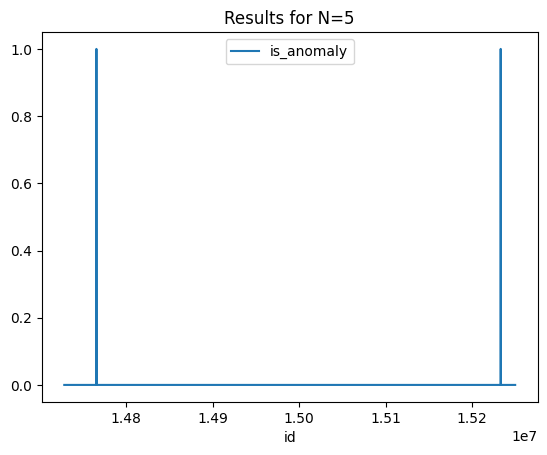

In [8]:
submission_df.plot("id", "is_anomaly", title=f"Results for N={N}")